<a href="https://colab.research.google.com/github/DoyelB06/LiverDiseasePrediction/blob/main/Liver_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()



Saving Indian Liver Patient Dataset (ILPD).csv to Indian Liver Patient Dataset (ILPD).csv



DATASET SHAPE
(582, 11)

FIRST FIVE RECORDS
   Age Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphatase  SGPT  \
0   62   Male             10.9               5.5                   699    64   
1   62   Male              7.3               4.1                   490    60   
2   58   Male              1.0               0.4                   182    14   
3   72   Male              3.9               2.0                   195    27   
4   46   Male              1.8               0.7                   208    19   

   SGOT  Total_Proteins  Albumin  AG_Ratio  Selector  
0   100             7.5      3.2      0.74         1  
1    68             7.0      3.3      0.89         1  
2    20             6.8      3.4      1.00         1  
3    59             7.3      2.4      0.40         1  
4    14             7.6      4.4      1.30         1  

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 11 columns):
 #   Column       

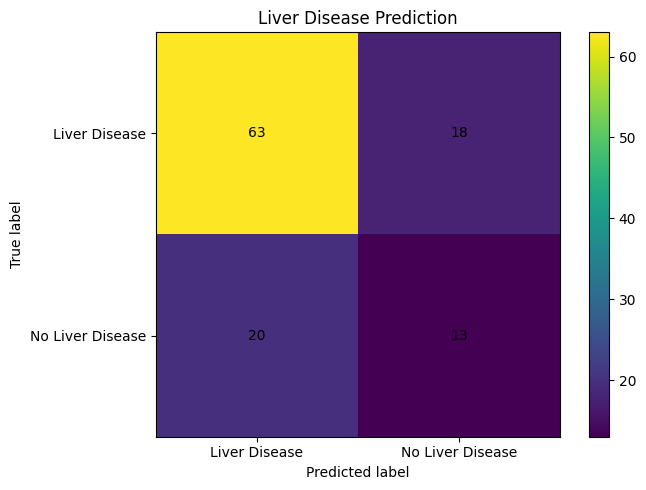

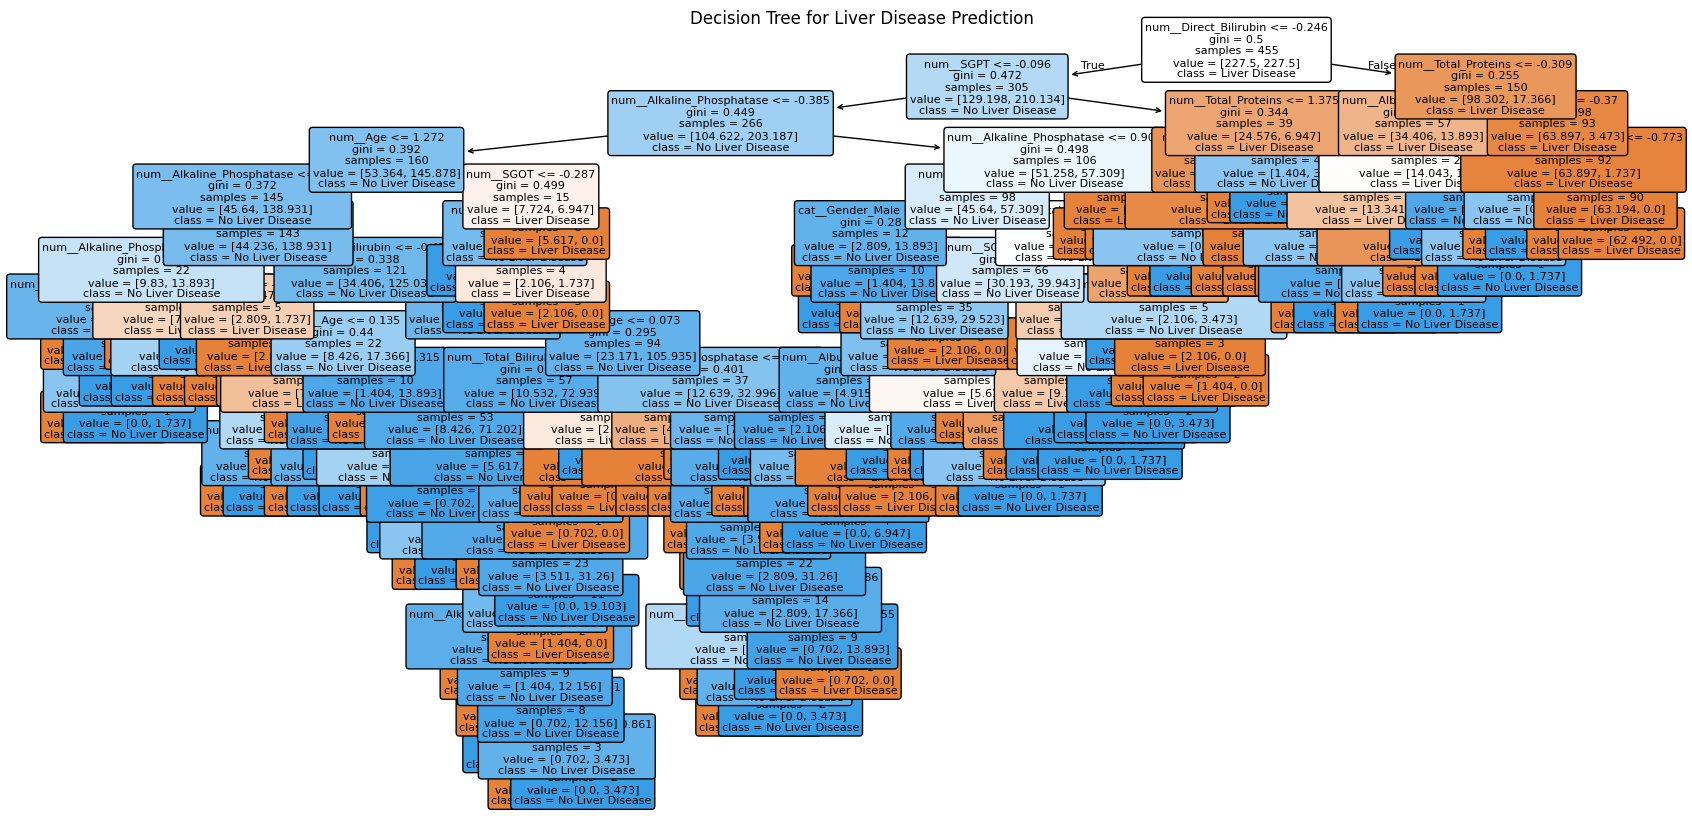


NEW PATIENT PREDICTION
Disease Status: Liver Disease


In [ ]:
# ============================================================
# Prediction of Liver Disease using Indian Liver Patient Dataset
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

file_path = "Indian Liver Patient Dataset (ILPD).csv"

df = pd.read_csv(file_path)

# ------------------------------------------------------------
# 2. ASSIGN COLUMN NAMES IF NECESSARY
# ------------------------------------------------------------

columns = [
    'Age',
    'Gender',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Alkaline_Phosphatase',
    'SGPT',
    'SGOT',
    'Total_Proteins',
    'Albumin',
    'AG_Ratio',
    'Selector'
]

# If column names are not correct, assign them
if len(df.columns) == 11 and list(df.columns) != columns:
    df.columns = columns

# ------------------------------------------------------------
# 3. DISPLAY DATASET INFORMATION
# ------------------------------------------------------------

print("\nDATASET SHAPE")
print(df.shape)

print("\nFIRST FIVE RECORDS")
print(df.head())

print("\nDATASET INFORMATION")
print(df.info())

print("\nDESCRIPTIVE STATISTICS")
print(df.describe())

print("\nMISSING-VALUE COUNT")
print(df.isnull().sum())

print("\nDUPLICATE COUNT")
print(df.duplicated().sum())

print("\nTARGET-CLASS DISTRIBUTION")
print(df['Selector'].value_counts())

# ------------------------------------------------------------
# 4. REMOVE DUPLICATE ROWS
# ------------------------------------------------------------

df = df.drop_duplicates()

print("\nSHAPE AFTER REMOVING DUPLICATES")
print(df.shape)

# ------------------------------------------------------------
# 5. REMOVE UNNECESSARY IDENTIFIER COLUMN IF PRESENT
# ------------------------------------------------------------

# Remove common unnecessary identifier columns if they exist
unnecessary_columns = ['ID', 'id', 'Patient_ID', 'PatientID']

for col in unnecessary_columns:
    if col in df.columns:
        df = df.drop(columns=[col])

# ------------------------------------------------------------
# 6 & 7. SELECT PREDICTORS
# ------------------------------------------------------------

predictor_columns = [
    'Age',
    'Gender',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Alkaline_Phosphatase',
    'SGPT',
    'SGOT',
    'Total_Proteins',
    'Albumin',
    'AG_Ratio'
]

X = df[predictor_columns]
y = df['Selector']

# ------------------------------------------------------------
# 9. IDENTIFY NUMERICAL AND CATEGORICAL VARIABLES
# ------------------------------------------------------------

numerical_features = [
    'Age',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Alkaline_Phosphatase',
    'SGPT',
    'SGOT',
    'Total_Proteins',
    'Albumin',
    'AG_Ratio'
]

categorical_features = ['Gender']

print("\nNUMERICAL VARIABLES")
print(numerical_features)

print("\nCATEGORICAL VARIABLES")
print(categorical_features)

# ------------------------------------------------------------
# 10. TRAIN-TEST SPLIT USING STRATIFICATION
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTRAINING RECORDS:", len(X_train))
print("TESTING RECORDS :", len(X_test))

# ------------------------------------------------------------
# 11. PREPROCESSING
# Numerical: Median Imputation -> StandardScaler
# Categorical: Most-Frequent Imputation -> OneHotEncoder
# ------------------------------------------------------------

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

# ------------------------------------------------------------
# 13 & 14. TARGET DISTRIBUTION / CLASS IMBALANCE
# ------------------------------------------------------------

print("\nTARGET DISTRIBUTION IN TRAINING DATA")
print(y_train.value_counts())

# Dataset is imbalanced, so use balanced class weights
class_weights = 'balanced'

# ------------------------------------------------------------
# 15. BUILD DECISION TREE CLASSIFIER
# ------------------------------------------------------------

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        class_weight=class_weights
    ))
])

# ------------------------------------------------------------
# 16. TRAIN MODEL
# ------------------------------------------------------------

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY")

# ------------------------------------------------------------
# 17. MODEL EVALUATION
# ------------------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=1
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1
)

cm = confusion_matrix(y_test, y_pred, labels=[1, 2])

print("\nMODEL EVALUATION")

print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))

print("\nCONFUSION MATRIX")
print(cm)

print("\nCLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Liver Disease', 'No Liver Disease']
    )
)

# ------------------------------------------------------------
# 18. DISPLAY CONFUSION MATRIX GRAPHICALLY
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Liver Disease Prediction")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(
    [0, 1],
    ['Liver Disease', 'No Liver Disease']
)

plt.yticks(
    [0, 1],
    ['Liver Disease', 'No Liver Disease']
)

# Add values inside cells
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 19. DISPLAY DECISION TREE
# ------------------------------------------------------------

# Get transformed feature names
feature_names = (
    model.named_steps['preprocessor']
    .get_feature_names_out()
)

tree_model = model.named_steps['classifier']

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=['Liver Disease', 'No Liver Disease'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Liver Disease Prediction")
plt.show()

# ------------------------------------------------------------
# 20. PREDICT STATUS OF NEW PATIENT
# ------------------------------------------------------------

new_patient = pd.DataFrame({
    'Age': [45],
    'Gender': ['Male'],
    'Total_Bilirubin': [1.5],
    'Direct_Bilirubin': [0.7],
    'Alkaline_Phosphatase': [200],
    'SGPT': [35],
    'SGOT': [40],
    'Total_Proteins': [6.5],
    'Albumin': [3.2],
    'AG_Ratio': [0.9]
})

prediction = model.predict(new_patient)[0]

print("\nNEW PATIENT PREDICTION")

if prediction == 1:
    print("Disease Status: Liver Disease")
else:
    print("Disease Status: No Liver Disease")